In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
# recommended styles: 'bmh' 'fivethirtyeight' 'ggplot' 'seaborn-darkgrid'
plt.style.use('bmh')
plt.rcParams['axes.axisbelow'] = True

In [3]:
import numpy as np
import pandas
import pandas as pd
from pandas import DataFrame, Index, Series, Timedelta, Timestamp


from tsdm.util.strings import snake2camel

rng = np.random.default_rng()
np.set_printoptions()

## Helper Functions

In [4]:
def data_overview(df: DataFrame):
    overview = DataFrame(index=df.columns)
    mask = pandas.isna(df)
    overview["# datapoints"] = (~mask).sum()
    overview["% missing"] = (mask.mean()*100).round(2)
    overview["min"] = df.min().round(2)
    overview["mean"] = df.mean().round(2)
    overview["std"] = df.std().round(2)
    overview["max"] = df.max().round(2)
    # overview["unit"] = units[df.columns]
    freq = {}
    for col in df:
        mask = pandas.notna(df[col])
        time = pandas.to_timedelta(df["timedelta"][mask], unit="s")
        freq[col] = time.mean()
    overview["freq"] = Series(freq).round("s").dt.to_pytimedelta().astype(str)
    overview.index.name = units.index.name
    return overview

In [5]:
from tsdm.datasets import KIWI_RUNS

data = KIWI_RUNS.timeseries.copy()
units = KIWI_RUNS.units.copy()
units["unit"] = units["unit"].cat.add_categories("s")
units.at["timedelta"] = "s"
units.at["freq"] = "s"
units

,unit
variable,
Flow_Air,Ln/min
StirringSpeed,U/min
Temperature,°C
Acetate,g/L
Base,uL
Cumulated_feed_volume_glucose,uL
Cumulated_feed_volume_medium,uL
DOT,%
Glucose,g/L


In [6]:
data["timedelta"] = Series(float('nan'), dtype="timedelta64[ns]")
for run_exp in data.reset_index(level=2).index.unique():
    time = Series(data.loc[run_exp].index)
    data.loc[run_exp, "timedelta"] =  (time.diff() /  Timedelta("1s")).values
data

variable                                  Flow_Air  StirringSpeed  \
run_id experiment_id measurement_time                               
355    11722         2019-04-09 18:32:12       0.0            0.0   
                     2019-04-09 18:32:18       0.0            0.0   
                     2019-04-09 18:32:19       0.0            0.0   
                     2019-04-09 18:32:21  4.997213            0.0   
                     2019-04-09 18:32:22  4.997213            0.0   
...                                            ...            ...   
510    16871         2021-10-26 22:41:26       5.0            0.0   
                     2021-10-26 22:42:11       5.0            0.0   
                     2021-10-26 22:42:20       5.0            0.0   
                     2021-10-26 22:43:22       5.0            0.0   
                     2021-10-26 22:43:31       5.0            0.0   

variable                                  Temperature  Acetate  Base  \
run_id experiment_id measurement_time                                  
355    11722         2019-04-09 18:32:12    36.990002     <NA>  <NA>   
                     2019-04-09 18:32:18         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:19         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:21         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:22        36.98     <NA>  <NA>   
...                                               ...      ...   ...   
510    16871         2021-10-26 22:41:26         <NA>     <NA>  <NA>   
                     2021-10-26 22:42:11    37.450001     <NA>  <NA>   
                     2021-10-26 22:42:20         <NA>     <NA>  <NA>   
                     2021-10-26 22:43:22    37.439999     <NA>  <NA>   
                     2021-10-26 22:43:31         <NA>     <NA>  <NA>   

variable                                  Cumulated_feed_volume_glucose  \
run_id experiment_id measurement_time                                     
355    11722         2019-04-09 18:32:12                            0.0   
                     2019-04-09 18:32:18                            0.0   
                     2019-04-09 18:32:19                            0.0   
                     2019-04-09 18:32:21                            0.0   
                     2019-04-09 18:32:22                            0.0   
...                                                                 ...   
510    16871         2021-10-26 22:41:26                         1061.0   
                     2021-10-26 22:42:11                         1061.0   
                     2021-10-26 22:42:20                         1061.0   
                     2021-10-26 22:43:22                         1061.0   
                     2021-10-26 22:43:31                         1061.0   

variable                                  Cumulated_feed_volume_medium  \
run_id experiment_id measurement_time                                    
355    11722         2019-04-09 18:32:12                           0.0   
                     2019-04-09 18:32:18                           0.0   
                     2019-04-09 18:32:19                           0.0   
                     2019-04-09 18:32:21                           0.0   
                     2019-04-09 18:32:22                           0.0   
...                                                                ...   
510    16871         2021-10-26 22:41:26                   3787.307373   
                     2021-10-26 22:42:11                   3787.307373   
                     2021-10-26 22:42:20                   3787.307373   
                     2021-10-26 22:43:22                   3787.307373   
                     2021-10-26 22:43:31                   3787.307373   

variable                                        DOT  Glucose  OD600  \
run_id experiment_id measurement_time                                 
355    11722         2019-04-09 18:32:12       <NA>     <NA>   <NA>   
             

In [7]:
data = data.astype("float32")
overviews = {}
for idx, slc in data.groupby(["run_id", "experiment_id"]):
    overviews[idx] = data_overview(slc)

In [8]:
omniview = pandas.concat(overviews, names=["run_id", "experiment_id"])

# datapoints  % missing  \
run_id experiment_id variable                                        
355    11722         Flow_Air                      3679       0.00   
                     StirringSpeed                 3679       0.00   
                     Temperature                    789      78.55   
                     Acetate                          8      99.78   
                     Base                           420      88.58   
...                                                 ...        ...   
510    16871         pH                             645      58.14   
                     Fluo_GFP                        12      99.22   
                     InducerConcentration          1541       0.00   
                     Volume                         181      88.25   
                     timedelta                     1540       0.06   

                                                   min          mean  \
run_id experiment_id variable                                          
355    11722         Flow_Air                 0.000000      4.990000   
                     StirringSpeed            0.000000   1493.069946   
                     Temperature             34.670000     37.000000   
                     Acetate                  0.100000      0.300000   
                     Base                    10.000000   1887.900024   
...                                                ...           ...   
510    16871         pH                       6.450000      6.960000   
                     Fluo_GFP              2653.750000  13371.250000   
                     InducerConcentration     0.000000      0.000000   
                     Volume                -313.529999    -34.220001   
                     timedelta                1.000000     31.530001   

                                                   std           max     freq  
run_id experiment_id variable                                                  
355    11722         Flow_Air                 0.220000      5.000000  0:00:13  
                     StirringSpeed          101.739998   1500.000000  0:00:13  
                     Temperature              0.120000     37.100000  0:00:36  
                     Acetate                  0.190000      0.540000  0:00:16  
                     Base                  1143.020020   3930.000000  0:00:21  
...                                                ...           ...      ...  
510    16871         pH                       0.170000      7.370000  0:00:20  
                     Fluo_GFP              9871.730469  30806.250000  0:00:04  
                     InducerConcentration     0.000000      0.000000  0:00:32  
                     Volume                 109.440002    243.070007  0:00:04  
                     timedelta               33.369999    521.000000  0:00:32  

[4224 rows x 7 columns]

In [11]:
omniview.groupby("variable").mean().round(2)

,# datapoints,% missing,min,mean,std,max
variable,,,,,,
Flow_Air,1673.89,0.00,0.00,5.610000,0.760000,5.91
StirringSpeed,1673.89,0.00,0.00,365.820007,85.580002,818.18
Temperature,594.55,62.73,34.02,37.299999,0.460000,39.79
Acetate,7.16,99.59,0.06,0.150000,0.090000,0.29
Base,65.39,97.06,20.02,397.459991,230.690002,784.58
Cumulated_feed_volume_glucose,1673.89,0.00,0.00,325.320007,338.459991,1055.16
Cumulated_feed_volume_medium,1673.89,0.00,0.00,1015.450012,609.429993,1893.56
DOT,740.41,52.58,11.06,71.660004,21.790001,98.25
Glucose,6.91,99.61,0.46,1.750000,1.760000,4.38


In [45]:
overview = data_overview(data.reset_index(level=[0, 1], drop=True))
overview["unit"] = units.loc[KIWI_RUNS.timeseries.columns]

with pd.option_context("display.float_format", "{:,.2f}".format):
    display(overview)

,# datapoints,% missing,min,mean,std,max,unit
Flow_Air,441907,0.00,0.00,5.52,1.69,10.00,Ln/min
StirringSpeed,441907,0.00,0.00,693.72,956.76,"2,600.00",U/min
Temperature,156960,64.48,32.69,37.31,0.52,41.38,°C
Acetate,1891,99.57,0.00,0.14,0.12,1.18,g/L
Base,17264,96.09,0.00,"1,172.01","1,125.71","4,070.00",uL
Cumulated_feed_volume_glucose,441907,0.00,0.00,397.87,543.72,"4,101.00",uL
Cumulated_feed_volume_medium,441907,0.00,0.00,"1,053.13","1,044.66","5,060.85",uL
DOT,195469,55.77,0.00,71.15,29.65,100.00,%
Glucose,1823,99.59,0.00,1.50,2.30,40.72,g/L
OD600,1819,99.59,0.01,9.22,9.38,127.88,%


## Some prep work

In [5]:
from tsdm.datasets import KIWI_RUNS

data = KIWI_RUNS.timeseries.copy()
units = KIWI_RUNS.units

,unit
variable,
Flow_Air,Ln/min
StirringSpeed,U/min
Temperature,°C
Acetate,g/L
Base,uL
Cumulated_feed_volume_glucose,uL
Cumulated_feed_volume_medium,uL
DOT,%
Glucose,g/L


## Overview Raw Data

In [8]:
overview = data_overview(data.reset_index(level=[0,1], drop=True))
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(overview)

KeyError: "None of [Index(['Flow_Air', 'StirringSpeed', 'Temperature', 'Acetate', 'Base',\n       'Cumulated_feed_volume_glucose', 'Cumulated_feed_volume_medium', 'DOT',\n       'Glucose', 'OD600', 'Probe_Volume', 'pH', 'Fluo_GFP',\n       'InducerConcentration', 'Volume'],\n      dtype='object')] are in the [columns]"

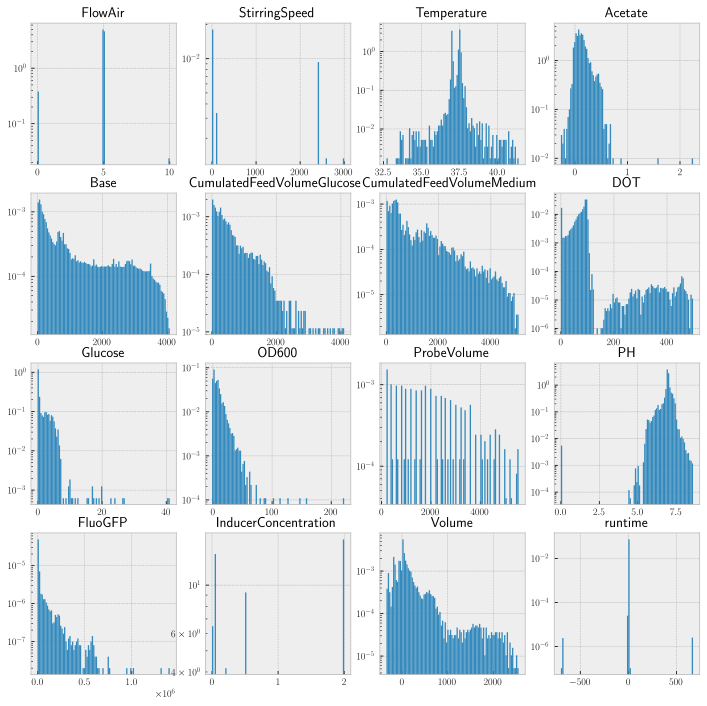

In [10]:
fig, axes = plt.subplots(ncols=4, nrows=4, figsize=(12, 12))
data["runtime"] = data["runtime"].diff()
for col, ax in zip(data, axes.flatten()):
    vals = data[col]
    mask = pandas.notna(vals)
    ax.hist(vals[mask], bins=100, density=True);
    ax.set_title(col)
    # ax.set_xscale("symlog")
    ax.set_yscale("log")

In [11]:
for col in ["OD600", "DOT", "Acetate", "Glucose"]:
    print(data[col][data[col]<0])

run_id  experiment_id  measurement_time   
355     11722          2019-04-10 07:28:04   -1.5625
        11724          2019-04-10 07:28:04   -0.5625
        11727          2019-04-10 07:28:04   -1.1625
                       2019-04-10 07:28:04   -0.7625
        11729          2019-04-10 07:28:04   -0.1625
                                               ...  
439     15346          2020-12-09 22:53:58   -0.0375
        15347          2020-12-09 22:53:58   -0.0375
        15348          2020-12-09 13:48:50   -0.0125
                       2020-12-09 13:48:50   -0.0525
                       2020-12-09 22:53:58   -0.0375
Name: OD600, Length: 65, dtype: float32
Series([], Name: DOT, dtype: float32)
run_id  experiment_id  measurement_time   
355     11722          2019-04-09 19:59:40   -0.003984
                       2019-04-09 23:00:54   -0.008745
                       2019-04-09 23:00:54   -0.019281
                       2019-04-10 00:02:13   -0.021980
                       2019-04-10

## Overview cleaned data

In [12]:
from tsdm.datasets import KIWI_RUNS
data = KIWI_RUNS.dataset
data = data.rename(columns={col:snake2camel(col) for col in data})

FlowAir  StirringSpeed  \
run_id experiment_id measurement_time                               
355    11722         2019-04-09 18:32:12      <NA>           <NA>   
                     2019-04-09 18:32:18      <NA>           <NA>   
                     2019-04-09 18:32:19      <NA>           <NA>   
                     2019-04-09 18:32:21  4.997213           <NA>   
                     2019-04-09 18:32:22  4.997213           <NA>   
...                                            ...            ...   
510    16871         2021-10-26 22:41:26       5.0            0.0   
                     2021-10-26 22:42:11       5.0            0.0   
                     2021-10-26 22:42:20       5.0            0.0   
                     2021-10-26 22:43:22       5.0            0.0   
                     2021-10-26 22:43:31       5.0            0.0   

                                          Temperature  Acetate  Base  \
run_id experiment_id measurement_time                                  
355    11722         2019-04-09 18:32:12    36.990002     <NA>  <NA>   
                     2019-04-09 18:32:18         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:19         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:21         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:22        36.98     <NA>  <NA>   
...                                               ...      ...   ...   
510    16871         2021-10-26 22:41:26         <NA>     <NA>  <NA>   
                     2021-10-26 22:42:11    37.450001     <NA>  <NA>   
                     2021-10-26 22:42:20         <NA>     <NA>  <NA>   
                     2021-10-26 22:43:22    37.439999     <NA>  <NA>   
                     2021-10-26 22:43:31         <NA>     <NA>  <NA>   

                                          CumulatedFeedVolumeGlucose  \
run_id experiment_id measurement_time                                  
355    11722         2019-04-09 18:32:12                        <NA>   
                     2019-04-09 18:32:18                        <NA>   
                     2019-04-09 18:32:19                        <NA>   
                     2019-04-09 18:32:21                        <NA>   
                     2019-04-09 18:32:22                        <NA>   
...                                                              ...   
510    16871         2021-10-26 22:41:26                      1061.0   
                     2021-10-26 22:42:11                      1061.0   
                     2021-10-26 22:42:20                      1061.0   
                     2021-10-26 22:43:22                      1061.0   
                     2021-10-26 22:43:31                      1061.0   

                                          CumulatedFeedVolumeMedium  \
run_id experiment_id measurement_time                                 
355    11722         2019-04-09 18:32:12                       <NA>   
                     2019-04-09 18:32:18                       <NA>   
                     2019-04-09 18:32:19                       <NA>   
                     2019-04-09 18:32:21                       <NA>   
                     2019-04-09 18:32:22                       <NA>   
...                                                             ...   
510    16871         2021-10-26 22:41:26                3787.307373   
                     2021-10-26 22:42:11                3787.307373   
                     2021-10-26 22:42:20                3787.307373   
                     2021-10-26 22:43:22                3787.307373   
                     2021-10-26 22:43:31                3787.307373   

                                                DOT  Glucose  OD600  \
run_id experiment_id measurement_time                                 
355    11722         2019-04-09 18:32:12       <NA>     <NA>   <NA>   
                     2019-04-09 18:32:18  89.660004     <NA>   <NA>   
                     2019-04-09 18:32:19       <NA>     <NA>   

In [13]:
for run_exp in data.reset_index(level=2).index.unique():
    time = data.loc[run_exp].index
    td = (time - time.min()) / Timedelta("1h")
    data.loc[run_exp, "runtime"] = td

overview = data_overview(data.reset_index(level=[0,1], drop=True))
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(overview)

,# datapoints,% missing,min,mean,std,max,unit,freq
FlowAir,439963,0.44,0.00,5.54,1.65,10.00,Ln/min,0:00:00
StirringSpeed,352014,20.34,0.00,870.88,997.43,"2,600.00",U/min,0:00:00
Temperature,156960,64.48,32.69,37.30,0.52,41.38,°C,0:00:00
Acetate,1891,99.57,0.00,0.14,0.12,1.18,g/L,0:00:24
Base,17264,96.09,0.00,"1,172.00","1,125.71","4,070.00",uL,0:00:03
CumulatedFeedVolumeGlucose,304491,31.10,3.00,577.42,570.41,"4,101.00",uL,0:00:00
CumulatedFeedVolumeMedium,422060,4.49,5.88,"1,102.65","1,043.09","5,060.85",uL,0:00:00
DOT,195469,55.77,0.00,71.15,29.65,100.00,%,0:00:00
Glucose,1823,99.59,0.00,1.50,2.30,40.72,g/L,0:00:25
OD600,1819,99.59,0.01,9.22,9.38,127.88,%,0:00:26


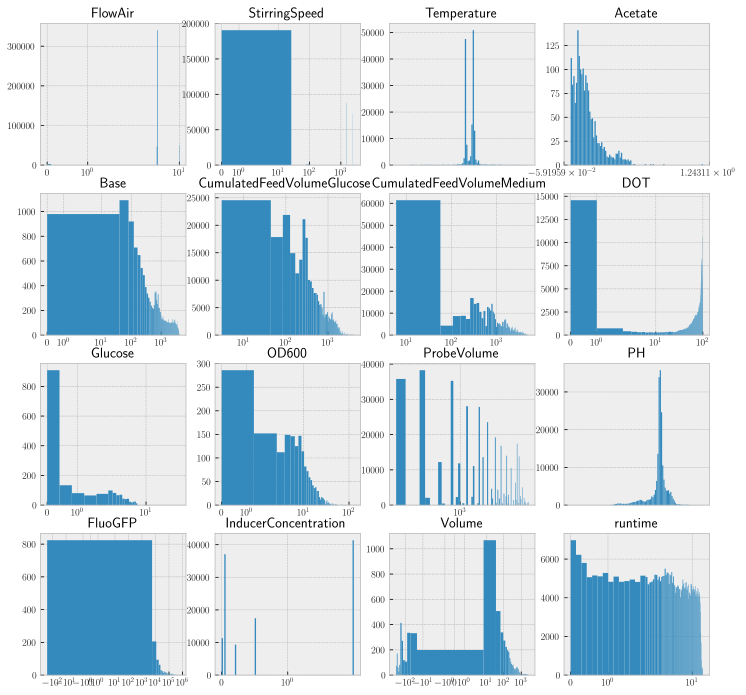

In [14]:
fig, axes = plt.subplots(ncols=4, nrows=4, figsize=(12, 12))

for col, ax in zip(data, axes.flatten()):
    vals = data[col]
    mask = pandas.notna(vals)
    ax.hist(vals[mask], bins=100);
    ax.set_title(col)
    ax.set_xscale("symlog")
    # ax.set_yscale("log")

## Overview Task data

pretty much the same as cleaned but without run 355

In [15]:
from tsdm.tasks import KIWI_RUNS_TASK

data = KIWI_RUNS_TASK().timeseries
data = data.rename(columns={col:snake2camel(col) for col in data})
for run_exp in data.reset_index(level=2).index.unique():
    time = data.loc[run_exp].index
    td = (time - time.min()) / Timedelta("1h")
    data.loc[run_exp, "runtime"] = td

overview = data_overview(data.reset_index(level=[0,1], drop=True))
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(overview)

,# datapoints,% missing,min,mean,std,max,unit,freq
FlowAir,351771,0.53,0.00,5.68,1.82,10.00,Ln/min,0:00:00
StirringSpeed,264158,25.30,0.00,661.64,"1,072.54","2,600.00",U/min,0:00:00
Temperature,138024,60.97,32.69,37.35,0.54,41.38,°C,0:00:00
Acetate,1677,99.53,0.00,0.13,0.10,1.18,g/L,0:00:27
Base,7184,97.97,5.00,311.32,327.28,"2,365.00",uL,0:00:04
CumulatedFeedVolumeGlucose,218507,38.21,3.00,480.77,563.03,"4,101.00",uL,0:00:00
CumulatedFeedVolumeMedium,335380,5.16,5.88,"1,219.05","1,135.86","5,060.85",uL,0:00:00
DOT,176533,50.08,0.00,74.19,27.58,100.00,%,0:00:00
Glucose,1604,99.55,0.00,1.62,2.39,40.72,g/L,0:00:28
OD600,1572,99.56,0.01,7.60,7.32,70.22,%,0:00:29


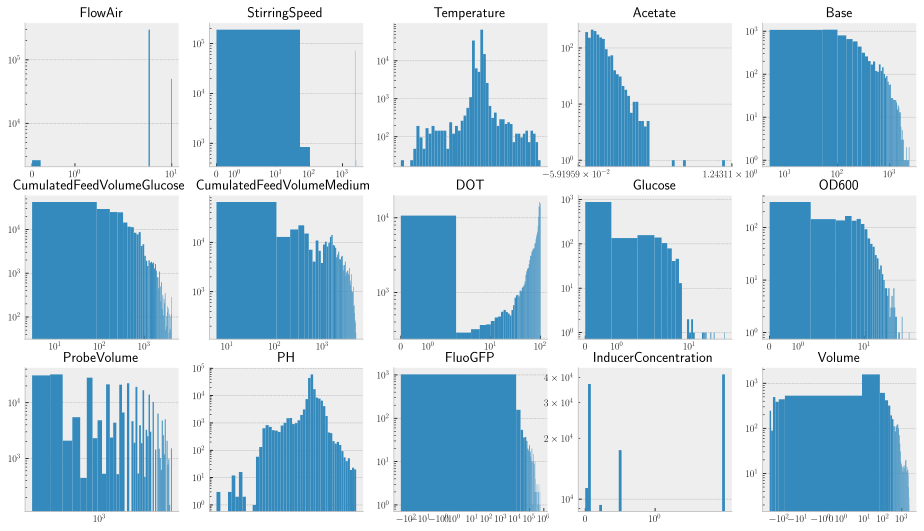

In [16]:

fig, axes = plt.subplots(ncols=5, nrows=3, figsize=(16, 9))

for col, ax in zip(data, axes.flatten()):
    vals = data[col]
    mask = pandas.notna(vals)
    ax.hist(vals[mask], bins=50);
    ax.set_title(col)
    ax.set_xscale("symlog")
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x")